# 空间变异分析：Meuse 河漫滩土壤锌（对数）半变异函数

本笔记演示：**经验半变异** → **理论协方差模型拟合** → **块金 / 部分基台 / 变程** 解释。

- **数据**：荷兰 Meuse 河漫滩土壤样点（R `sp::meuse` 的经典教学数据；本仓库通过 CSV 镜像获取）。
- **区域化变量**：`log(zinc)`（ppm），与多数 `gstat` 教程一致，使方差更平稳。
- **坐标**：`x`, `y` 为荷兰 RD 新坐标（EPSG:28992 所用米制网格），分析中仅使用平面欧氏距离。

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gstools as gs

plt.style.use("seaborn-v0_8-whitegrid")


def repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in (cwd, *cwd.parents):
        if (p / "requirements.txt").is_file() and (p / "data").is_dir():
            return p
    return cwd


ROOT = repo_root()
DATA = ROOT / "data" / "processed" / "meuse.csv"
OUT = ROOT / "outputs"
OUT.mkdir(parents=True, exist_ok=True)
print("Repository root:", ROOT)

Matplotlib is building the font cache; this may take a moment.


Repository root: /Users/joeyzhang/workspace/Spatial_Analysis


In [2]:
df = pd.read_csv(DATA)
# 与 R 中一致：对锌取对数
df["log_zinc"] = np.log(df["zinc"])
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["x"], df["y"]), crs="EPSG:28992")
gdf.head()

,x,y,cadmium,copper,lead,zinc,elev,dist,om,ffreq,soil,lime,landuse,dist.m,log_zinc,geometry
0,181072,333611,11.7,85,299,1022,7.909,0.001358,13.6,1,1,1,Ah,50,6.929517,POINT (181072 333611)
1,181025,333558,8.6,81,277,1141,6.983,0.012224,14.0,1,1,1,Ah,30,7.039660,POINT (181025 333558)
2,181165,333537,6.5,68,199,640,7.800,0.103029,13.0,1,1,1,Ah,150,6.461468,POINT (181165 333537)
3,181298,333484,2.6,81,116,257,7.655,0.190094,8.0,1,2,0,Ga,270,5.549076,POINT (181298 333484)
4,181307,333330,2.8,48,117,269,7.480,0.277090,8.7,1,2,0,Ah,380,5.594711,POINT (181307 333330)


/var/folders/09/8sk21x416113gfzf1f6_ds600000gn/T/ipykernel_80089/2658293699.py:9: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/09/8sk21x416113gfzf1f6_ds600000gn/T/ipykernel_80089/2658293699.py:9: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/09/8sk21x416113gfzf1f6_ds600000gn/T/ipykernel_80089/2658293699.py:9: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/09/8sk21x416113gfzf1f6_ds600000gn/T/ipykernel_80089/2658293699.py:9: UserWarning: Glyph 38156 (\N{CJK UNIFIED IDEOGRAPH-950C}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/09/8sk21x416113gfzf1f6_ds600000gn/T/ipykernel_80089/2658293699.py:9: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/09/8sk21x416113gfzf1f6_ds600000gn/T/ipyker

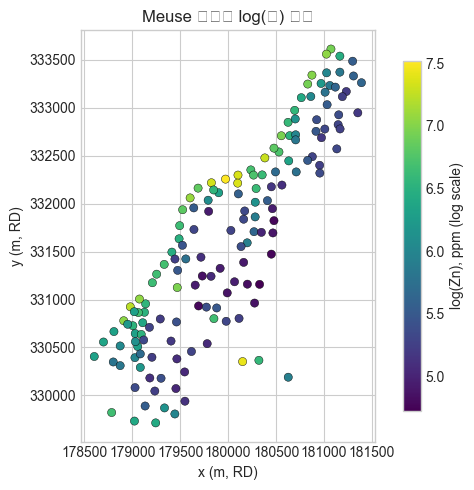

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(gdf["x"], gdf["y"], c=gdf["log_zinc"], cmap="viridis", s=35, edgecolor="k", linewidths=0.3)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x (m, RD)")
ax.set_ylabel("y (m, RD)")
cb = plt.colorbar(sc, ax=ax, shrink=0.85)
cb.set_label("log(Zn), ppm (log scale)")
ax.set_title("Meuse 样点与 log(锌) 分布")
fig.tight_layout()
fig.savefig(OUT / "meuse_logzn_points.png", dpi=150)
plt.show()

/var/folders/09/8sk21x416113gfzf1f6_ds600000gn/T/ipykernel_80089/2354614843.py:23: UserWarning: Glyph 28382 (\N{CJK UNIFIED IDEOGRAPH-6EDE}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/09/8sk21x416113gfzf1f6_ds600000gn/T/ipykernel_80089/2354614843.py:23: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/09/8sk21x416113gfzf1f6_ds600000gn/T/ipykernel_80089/2354614843.py:23: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/09/8sk21x416113gfzf1f6_ds600000gn/T/ipykernel_80089/2354614843.py:23: UserWarning: Glyph 31163 (\N{CJK UNIFIED IDEOGRAPH-79BB}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/09/8sk21x416113gfzf1f6_ds600000gn/T/ipykernel_80089/2354614843.py:23: UserWarning: Glyph 32463 (\N{CJK UNIFIED IDEOGRAPH-7ECF}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/09/8sk21x416113gfzf1f6_ds600000gn/T/i

/Users/joeyzhang/workspace/Spatial_Analysis/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 32463 (\N{CJK UNIFIED IDEOGRAPH-7ECF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/joeyzhang/workspace/Spatial_Analysis/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/joeyzhang/workspace/Spatial_Analysis/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21322 (\N{CJK UNIFIED IDEOGRAPH-534A}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/joeyzhang/workspace/Spatial_Analysis/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/joeyzhang/workspace/Spatial_Analysis/.ven

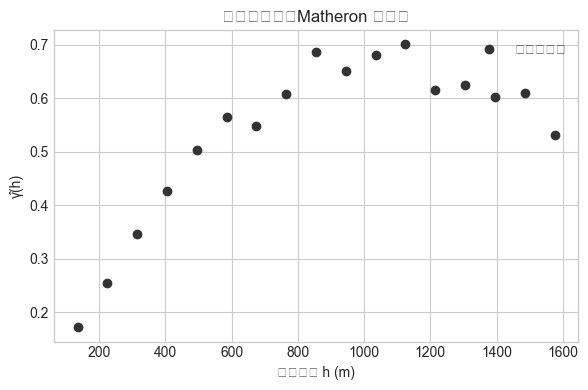

[(np.int64(135), np.float64(0.1719), np.int64(212)),
 (np.int64(225), np.float64(0.2555), np.int64(320)),
 (np.int64(315), np.float64(0.3469), np.int64(371)),
 (np.int64(405), np.float64(0.4263), np.int64(422)),
 (np.int64(495), np.float64(0.5033), np.int64(459)),
 (np.int64(585), np.float64(0.565), np.int64(455)),
 (np.int64(675), np.float64(0.5479), np.int64(466)),
 (np.int64(765), np.float64(0.6077), np.int64(503))]

In [4]:
pos = np.array([gdf["x"].to_numpy(), gdf["y"].to_numpy()])
field = gdf["log_zinc"].to_numpy()

max_lag = 1600.0
width = 90.0
bin_edges = np.arange(width, max_lag + width, width)

bin_center, emp_gamma, counts = gs.vario_estimate(
    pos,
    field,
    bin_edges,
    estimator="matheron",
    mesh_type="unstructured",
    return_counts=True,
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(bin_center, emp_gamma, "o", color="0.2", label="经验半变异")
ax.set_xlabel("滞后距离 h (m)")
ax.set_ylabel("γ̂(h)")
ax.set_title("经验半变异（Matheron 估计）")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "empirical_variogram.png", dpi=150)
plt.show()

list(zip(np.round(bin_center).astype(int), np.round(emp_gamma, 4), counts))[:8]

In [5]:
candidates = {
    "Spherical": gs.Spherical(dim=2),
    "Exponential": gs.Exponential(dim=2),
    "Gaussian": gs.Gaussian(dim=2),
}

fits = {}
for name, model in candidates.items():
    m = model
    m.fit_variogram(bin_center, emp_gamma, nugget=True)
    fits[name] = m
    print(
        f"{name:12s}  nugget={m.nugget:.4f}  partial_sill={m.var:.4f}  len_scale={m.len_scale:.1f} m"
    )

Spherical     nugget=0.0368  partial_sill=0.5940  len_scale=870.3 m
Exponential   nugget=0.0000  partial_sill=0.6550  len_scale=353.4 m
Gaussian      nugget=0.1265  partial_sill=0.5038  len_scale=373.6 m


各模型 RMS（γ 域）: {'Spherical': 0.03805, 'Exponential': 0.05068, 'Gaussian': 0.03871}
主展示模型: Spherical


/var/folders/09/8sk21x416113gfzf1f6_ds600000gn/T/ipykernel_80089/3370926176.py:22: UserWarning: Glyph 28382 (\N{CJK UNIFIED IDEOGRAPH-6EDE}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/09/8sk21x416113gfzf1f6_ds600000gn/T/ipykernel_80089/3370926176.py:22: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/09/8sk21x416113gfzf1f6_ds600000gn/T/ipykernel_80089/3370926176.py:22: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/09/8sk21x416113gfzf1f6_ds600000gn/T/ipykernel_80089/3370926176.py:22: UserWarning: Glyph 31163 (\N{CJK UNIFIED IDEOGRAPH-79BB}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/09/8sk21x416113gfzf1f6_ds600000gn/T/ipykernel_80089/3370926176.py:22: UserWarning: Glyph 29702 (\N{CJK UNIFIED IDEOGRAPH-7406}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/09/8sk21x416113gfzf1f6_ds600000gn/T/i

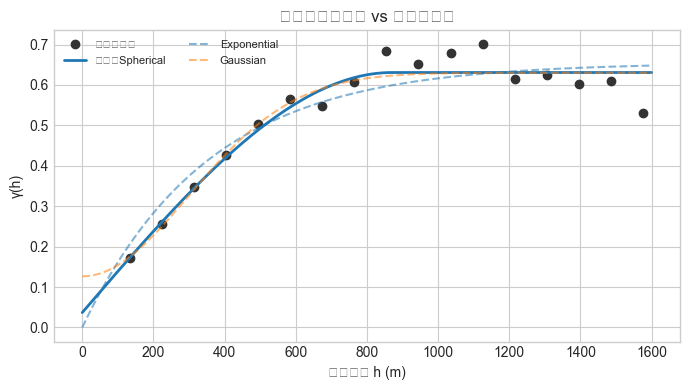

In [6]:
errs = {}
x = np.linspace(0, float(max_lag), 200)
for name, m in fits.items():
    errs[name] = float(np.sqrt(np.mean((m.variogram(bin_center) - emp_gamma) ** 2)))

best = min(errs, key=errs.get)
print("各模型 RMS（γ 域）:", {k: round(v, 5) for k, v in errs.items()})
print("主展示模型:", best)
best_m = fits[best]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bin_center, emp_gamma, "o", color="0.2", label="经验半变异")
ax.plot(x, best_m.variogram(x), "-", color="C0", linewidth=2, label=f"拟合：{best}")
for name, m in fits.items():
    if name == best:
        continue
    ax.plot(x, m.variogram(x), "--", alpha=0.55, label=f"{name}")
ax.set_xlabel("滞后距离 h (m)")
ax.set_ylabel("γ(h)")
ax.set_title("理论半变异模型 vs 经验半变异")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "fitted_variogram_models.png", dpi=150)
plt.show()

In [7]:
nug = float(best_m.nugget)
ps = float(best_m.var)
sill = nug + ps
print(f"块金 (nugget): {nug:.4f}")
print(f"部分基台 (partial sill): {ps:.4f}")
print(f"总基台 (approx. sill): {sill:.4f}")
print(f"相关长度参数 len_scale: {float(best_m.len_scale):.1f} m")

if best == "Spherical":
    eff_range = float(best_m.len_scale)
elif best == "Exponential":
    eff_range = float(3 * best_m.len_scale)
elif best == "Gaussian":
    eff_range = float(np.sqrt(3) * best_m.len_scale)
else:
    eff_range = float("nan")
print(f"经验有效相关距离（常用换算，模型={best}）: ~{eff_range:.0f} m")

块金 (nugget): 0.0368
部分基台 (partial sill): 0.5940
总基台 (approx. sill): 0.6308
相关长度参数 len_scale: 870.3 m
经验有效相关距离（常用换算，模型=Spherical）: ~870 m


### 小结与局限

- **块金**反映小于最小采样间距的变异与测量误差；**基台**刻画空间相关所能解释的方差份额；**变程尺度**给出相似性随距离衰减的大致距离。
- 本笔记**未做**各向异性、稳健估计与交叉验证；若样本存在趋势，应先去趋势再估计变异函数（见仓库 README 参考文献）。